# Step 1: Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline     
sns.set(color_codes=True)

# Step 2: Load the Dataset

In [20]:
df = pd.read_csv('fraudTrain.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

# Step 3: Data Preprocessing

##  3.1 Missing Value checking

In [22]:
# Check for missing values
print(df.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


No missing values /

## 3.2 Dupplication checking

In [23]:
# Check for duplicate rows
duplicates = df.duplicated()
print(df[duplicates])

Empty DataFrame
Columns: [Unnamed: 0, trans_date_trans_time, cc_num, merchant, category, amt, first, last, gender, street, city, state, zip, lat, long, city_pop, job, dob, trans_num, unix_time, merch_lat, merch_long, is_fraud]
Index: []

[0 rows x 23 columns]


No Dupplication /

In [26]:
# Summary statistics for the 'amt' column because it is the only numerical value here
print(df['amt'].describe())

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64


So, we are dealing with amount of money from 1 to 22,768 usd(s) with other descriptive statistics

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

Checking the info of this dataframe

In [28]:
df.nunique()

Unnamed: 0               1296675
trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
dtype: int64

# Understanding the dataset
### 1. There are 555,719 rows of data (entries)
### 2. There are 23 columns. Mainly about bank transactions
#### 2.1 Purely Transaction Related columns:
  * trans_date_trans_time --> Timestamp of each data row
  * merchant --> business names where transaction happened
  * category --> what kind of service
  * amt --> Amount in each transaction (Float)
  * trans_num --> unique id of each transaction
  * unix_time --> Similar to timestamp but with UNIX system where It’s the number of seconds since the start of 1. January 1970 UTC.
  * merch_lat --> Latitude of business/transaction?
  * merch_long --> Longtitude of business/transaction?
  * is_fraud --> Our Target! 1= True, it is a fraud transation. 0 = No,it is a normal transaction
#### 2.2 Biographic of customers
  * first --> Firstname, which may not any impact on the analysis
  * last  --> Lastname, which may not any impact on the analysis
  * gender --> Binary values. F : Female, M : Male
  * street --> String
  * city --> String
  * state --> States in USA
  * zip   --> Zipcode
  * lat --> Latitude of customer address?
  * long--> Longtitude of customer address?
  * city_pop --> City Population?
  * job --> Categorical
  * dob --> Date of Birth
### 3.Unneccessary columns for analysis
* Unnamed: 0 --> Dupplicate id as python already provide
* first --> First name doesn't matter
* last --> Also as Last name
So, I'll drop them three.

### 4.Columns I don't understand --> Undersatnd now
* cc_num

## 3.3 Dropping irrelevant columns

In [17]:
df = df.drop(['Unnamed: 0', 'first', 'last'], axis=1)
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [29]:
import pandas as pd

# Assuming you already have your DataFrame df
# df = pd.DataFrame(data)

# Define your job categories mapping
job_categories = {
    "Engineering": [
        "Mechanical engineer", "Materials engineer", "Energy engineer",
        "Petroleum engineer", "Electrical engineer", "Electronics engineer",
        "Automotive engineer", "Aeronautical engineer", "Biomedical engineer",
        "Chemical engineer", "Civil engineer, contracting", "Engineer, civil (contracting)",
        "Mining engineer", "Manufacturing engineer", "Structural engineer",
        "Field trials officer", "Engineer, building services", "Engineering geologist",
        "Engineer, control and instrumentation", "Engineer, maintenance", "Engineer, petroleum",
        "Engineer, aeronautical", "Engineer, civil (consulting)", "Engineer, manufacturing",
        "Engineer, water"
    ],
    "IT and Media": [
        "Sales professional, IT", "Web designer", "Programmer, multimedia",
        "Systems developer", "Applications developer", "Multimedia programmer",
        "Database administrator", "IT consultant", "Software engineer"
    ],
    "Healthcare": [
        "Psychotherapist", "Therapist, occupational", "Paramedic",
        "Radiographer, therapeutic", "Learning disability nurse",
        "Clinical research associate", "Neurosurgeon", "Music therapist",
        "Psychiatric nurse", "Clinical psychologist", "Psychologist, clinical",
        "Orthoptist", "Occupational therapist", "Art therapist", "Physiotherapist",
        "Pharmacist, hospital", "Speech and language therapist", "Dance movement psychotherapist",
        "Physiological scientist", "Radiographer, diagnostic", "Medical physicist",
        "Health physicist", "Counsellor", "Psychotherapist, child", "Psychologist, forensic",
        "Therapist, sports", "Therapist, art", "Therapist, horticultural", "Therapist, music"
    ],
    ""
    # Add more categories and jobs as needed
}

# Create a function to map job titles to categories
def map_job_to_category(job):
    for category, job_list in job_categories.items():
        if job in job_list:
            return category
    return "Other"  # If job doesn't match any category, return "Other"

# Apply the mapping function to the 'job' column in your existing DataFrame df
df['category'] = df['job'].apply(map_job_to_category)

# Print the updated DataFrame to verify
df.head(20)


SyntaxError: ':' expected after dictionary key (2354794480.py, line 35)

In [30]:
df['category'].nunique()

14

In [31]:
# Count of unique categories
unique_category_count = df['category'].nunique()

# List of unique categories and their counts
unique_categories = df['category'].value_counts()

print(f"Number of unique categories: {unique_category_count}")
print("Unique categories and their counts:")
print(unique_categories)


Number of unique categories: 14
Unique categories and their counts:
category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64


# Step 5: Exploratory Data Analysis (EDA)

## 1. Is the data balance?

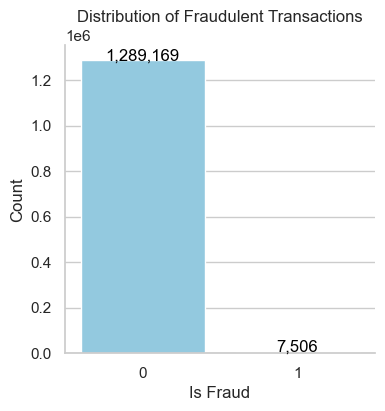

In [32]:
# Count the occurrences of each value in the is_fraud column
fraud_counts = df['is_fraud'].value_counts().reset_index()
fraud_counts.columns = ['is_fraud', 'count']

# Create a bar plot
plt.figure(figsize=(4, 4))
sns.set(style="whitegrid")
sns.barplot(x='is_fraud', y='count', data=fraud_counts, palette=['skyblue', 'salmon'])

# Annotate the bars with the count values formatted with commas
for index, row in fraud_counts.iterrows():
    plt.text(row.name, row['count'], f'{row["count"]:,}', color='black', ha="center")

# Set the title and labels
plt.title('Distribution of Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')

# Remove the top and right spines
sns.despine()

# Show the plot
plt.show()


In [33]:
# Calculate the total number of transactions
total_transactions = df['is_fraud'].count()

# Calculate the number of fraudulent transactions
fraudulent_transactions = fraud_counts.loc[fraud_counts['is_fraud'] == 1, 'count'].values[0]

# Calculate the percentage of fraudulent transactions
fraudulent_percentage = (fraudulent_transactions / total_transactions) * 100
print(f"Percentage of fraudulent transactions: {fraudulent_percentage:.2f}%")

Percentage of fraudulent transactions: 0.58%


The bar chart effectively show us that our dataset is highly imbalanced with 7,506 fraudulent cases in 1,289,169 transaction (0.58%)

## 2. Distribution of Transactions amount

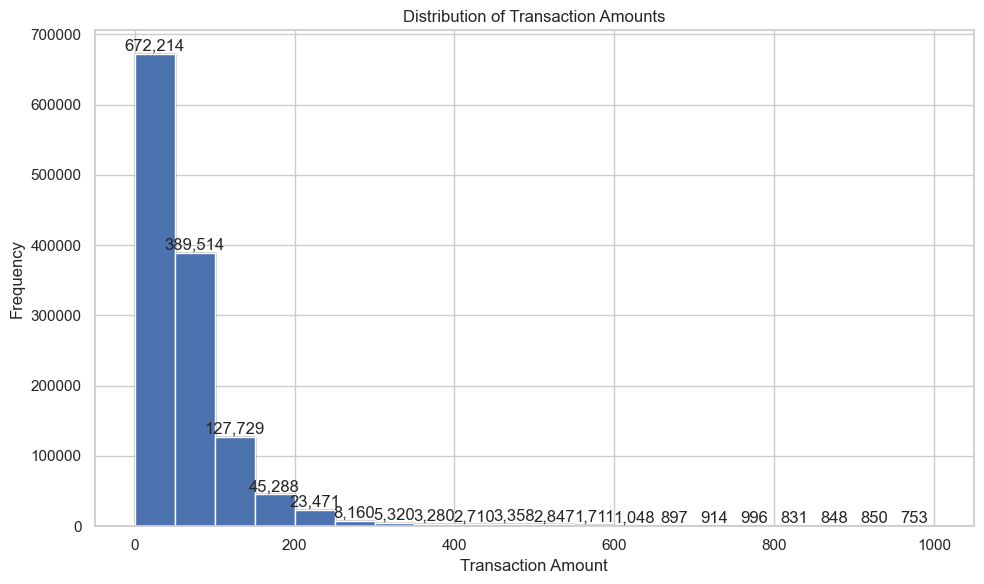

In [34]:
import matplotlib.pyplot as plt

# Define the intervals
intervals = [i for i in range(0, 1001, 50)]

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(df['amt'], bins=intervals, color='skyblue', edgecolor='black')

# Annotate each bar with its formatted frequency value
for i, freq in enumerate(plt.hist(df['amt'], bins=intervals)[0]):
    plt.text(intervals[i] + (intervals[i+1] - intervals[i])/2, freq, '{:,}'.format(int(freq)), ha='center', va='bottom')

# Set the title and labels
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


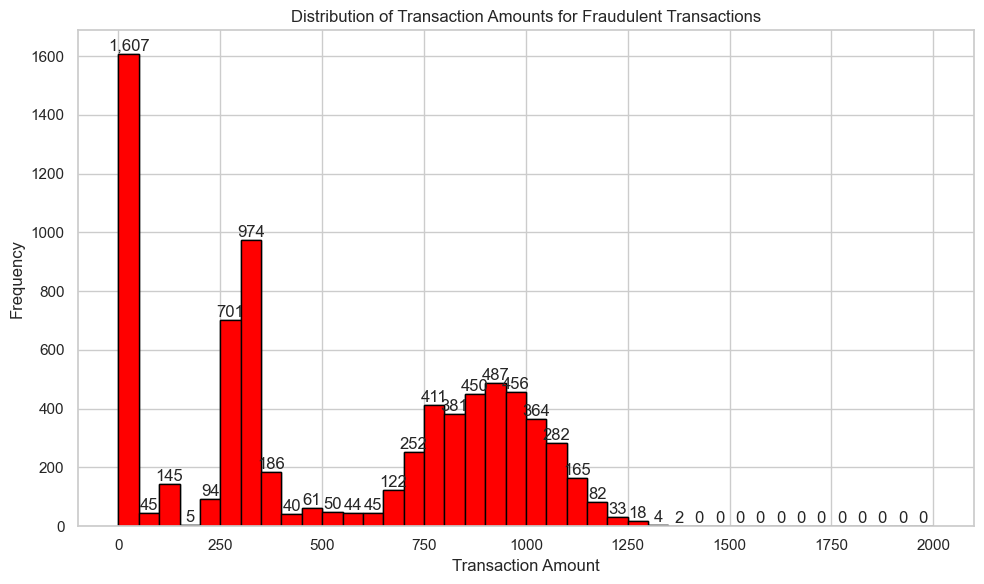

In [35]:
import matplotlib.pyplot as plt

# Define the intervals
intervals = [i for i in range(0, 2001, 50)]

# Filter the DataFrame for fraudulent transactions
fraudulent_data = df[df['is_fraud'] == 1]

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(fraudulent_data['amt'], bins=intervals, color='red', edgecolor='black')

# Annotate each bar with its formatted frequency value
for i, freq in enumerate(plt.hist(fraudulent_data['amt'], bins=intervals, color='red', edgecolor='black')[0]):
    plt.text(intervals[i] + (intervals[i+1] - intervals[i])/2, freq, '{:,}'.format(int(freq)), ha='center', va='bottom')

# Set the title and labels
plt.title('Distribution of Transaction Amounts for Fraudulent Transactions')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


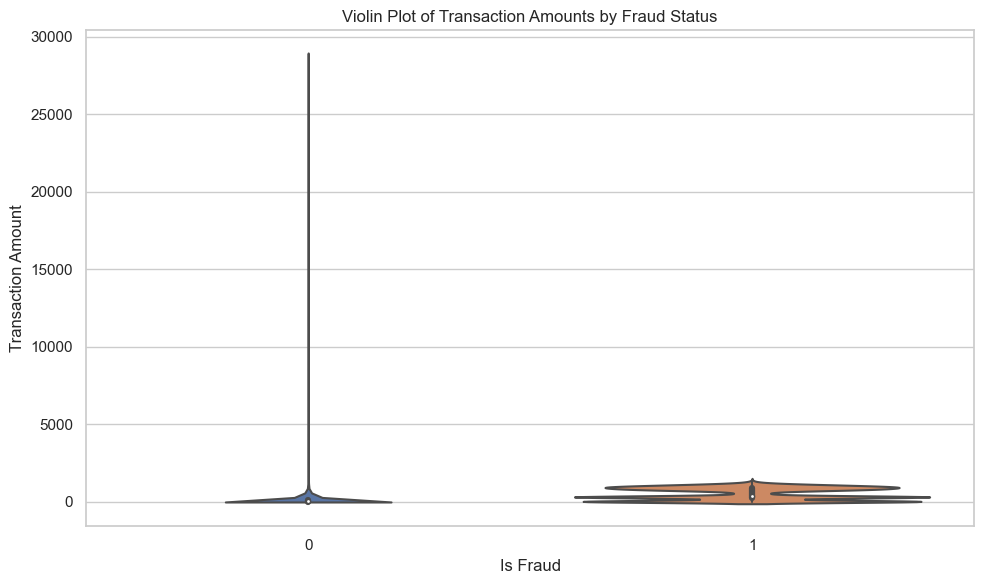

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions (is_fraud = 0 and is_fraud = 1)
fraudulent_data = df[df['is_fraud'].isin([0, 1])]

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='is_fraud', y='amt', data=fraudulent_data)

# Set the title and labels
plt.title('Violin Plot of Transaction Amounts by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')

# Show the plot
plt.tight_layout()
plt.show()


The violin chart clearly shows us that normal Transaction amount data has outliers --> need to clean later

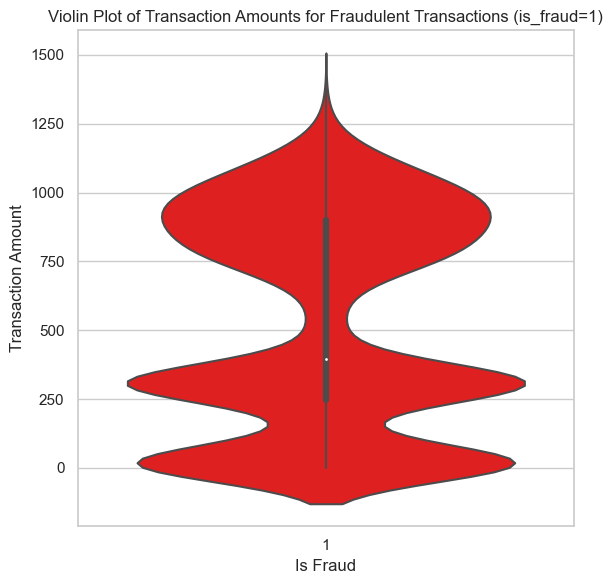

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions (is_fraud = 1)
fraudulent_data = df[df['is_fraud'] == 1]

# Create the violin plot for fraudulent transactions only
plt.figure(figsize=(6, 6))
sns.violinplot(x=fraudulent_data['is_fraud'], y=fraudulent_data['amt'], color='red')

# Set the title and labels
plt.title('Violin Plot of Transaction Amounts for Fraudulent Transactions (is_fraud=1)')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')

# Show the plot
plt.tight_layout()
plt.show()


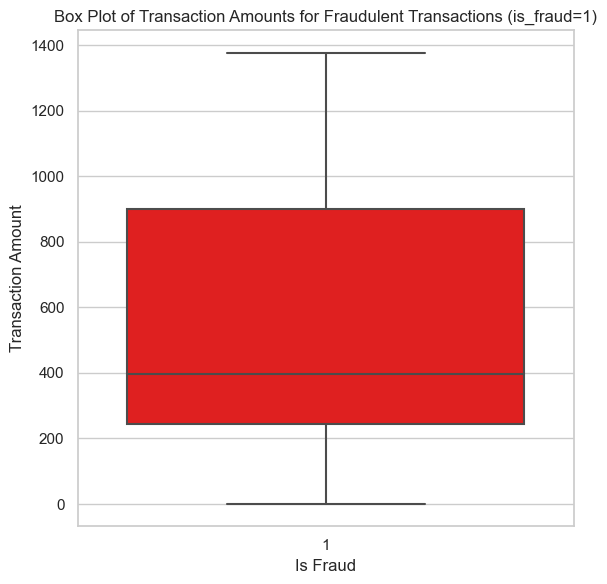

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions (is_fraud = 1)
fraudulent_data = df[df['is_fraud'] == 1]

# Create the box plot for fraudulent transactions only
plt.figure(figsize=(6, 6))
sns.boxplot(x=fraudulent_data['is_fraud'], y=fraudulent_data['amt'], color='red')

# Set the title and labels
plt.title('Box Plot of Transaction Amounts for Fraudulent Transactions (is_fraud=1)')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')

# Show the plot
plt.tight_layout()
plt.show()


When it comes to Fraud data it seems to be more consistent with specific amount 

In [39]:
# Filter the DataFrame for fraudulent transactions (is_fraud = 1)
fraudulent_data = df[df['is_fraud'] == 1]

# Calculate descriptive statistics for the 'amt' column
descriptive_stats = fraudulent_data['amt'].describe()

# Round the descriptive statistics to two decimal places
descriptive_stats_rounded = descriptive_stats.round(2)

# Print the rounded descriptive statistics
print(descriptive_stats_rounded)


count    7506.00
mean      531.32
std       390.56
min         1.06
25%       245.66
50%       396.50
75%       900.88
max      1376.04
Name: amt, dtype: float64


In [40]:
# Filter the DataFrame for fraudulent transactions (is_fraud = 1)
fraudulent_data = df[df['is_fraud'] == 1]

# Calculate the frequency of each value in the 'amt' column for fraudulent transactions
amt_value_counts = fraudulent_data['amt'].value_counts()

# Select the top 5 modes along with their frequencies
top5_modes_with_frequency = amt_value_counts.head(5)

# Print the top 5 modes with their frequencies
print("Top 5 modes of 'amt' for fraudulent transactions and their frequencies:")
print(top5_modes_with_frequency)


Top 5 modes of 'amt' for fraudulent transactions and their frequencies:
amt
8.75     6
18.55    6
18.96    5
9.95     5
7.04     5
Name: count, dtype: int64


Seems like there is no popular amount for fraud data

## 3.What is the distribution of transaction categories?

In [41]:
# Count the occurrences of each transaction category
category_counts = df['category'].value_counts()

# Calculate the proportion of transactions in each category
category_proportions = category_counts / len(df) * 100  # Calculate percentages

# Print the distribution of transaction categories
print("Distribution of Transaction Categories:")
for category, count in category_counts.items():
    proportion = category_proportions[category]
    print(f"- {category}: {count} transactions ({proportion:.2f}%)")


Distribution of Transaction Categories:
- gas_transport: 131659 transactions (10.15%)
- grocery_pos: 123638 transactions (9.54%)
- home: 123115 transactions (9.49%)
- shopping_pos: 116672 transactions (9.00%)
- kids_pets: 113035 transactions (8.72%)
- shopping_net: 97543 transactions (7.52%)
- entertainment: 94014 transactions (7.25%)
- food_dining: 91461 transactions (7.05%)
- personal_care: 90758 transactions (7.00%)
- health_fitness: 85879 transactions (6.62%)
- misc_pos: 79655 transactions (6.14%)
- misc_net: 63287 transactions (4.88%)
- grocery_net: 45452 transactions (3.51%)
- travel: 40507 transactions (3.12%)


C:\Users\Daisy\AppData\Local\Temp\ipykernel_14312\655092609.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, count + 0.5, f'{category_proportions[i]:.2f}%', ha='center')


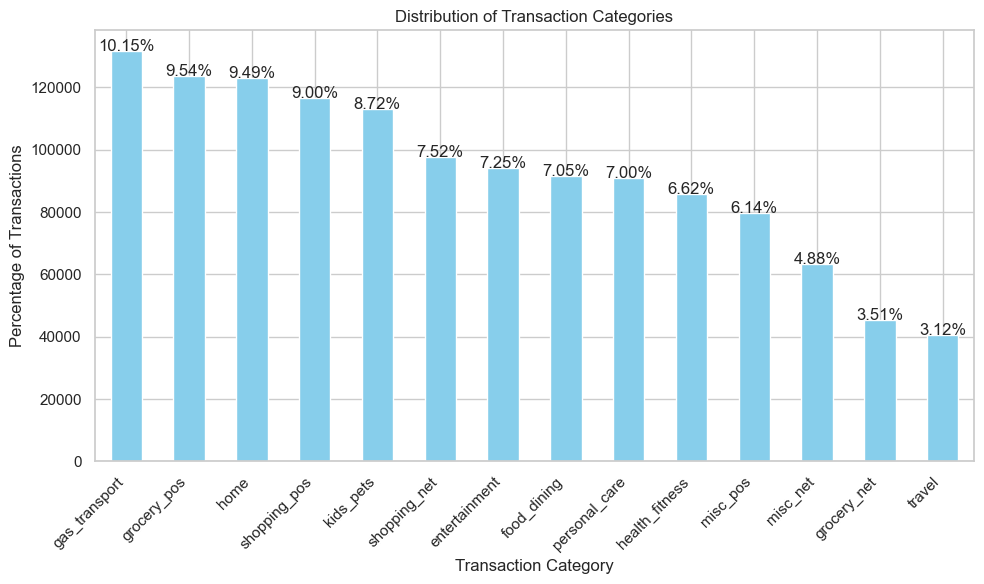

In [42]:
import matplotlib.pyplot as plt

# Plot the bar chart
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue')

# Set the title and labels
plt.title('Distribution of Transaction Categories')
plt.xlabel('Transaction Category')
plt.ylabel('Percentage of Transactions')

# Display the percentages on top of the bars
for i, count in enumerate(category_counts):
    plt.text(i, count + 0.5, f'{category_proportions[i]:.2f}%', ha='center')

# Show the plot
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4.Is there any correlation between transaction amount and whether it is a fraudulent transaction?

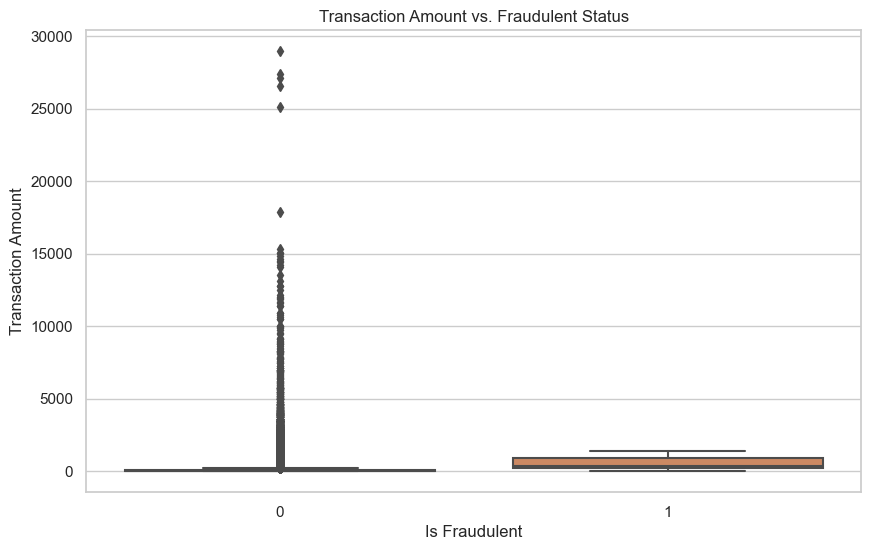

Correlation coefficient between transaction amount and fraudulent status: 0.2194038889588777


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot or box plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title('Transaction Amount vs. Fraudulent Status')
plt.xlabel('Is Fraudulent')
plt.ylabel('Transaction Amount')
plt.show()

# Calculate Pearson correlation coefficient
correlation_coefficient = df['amt'].corr(df['is_fraud'])

# Print the correlation coefficient
print("Correlation coefficient between transaction amount and fraudulent status:", correlation_coefficient)


0.22 seems to be a poor correlation

## 5. What is the distribution of fraudulent transactions over time (e.g., by month, day of the week, hour)?

The data runfrom 21/06/2020 - 31/12/2020

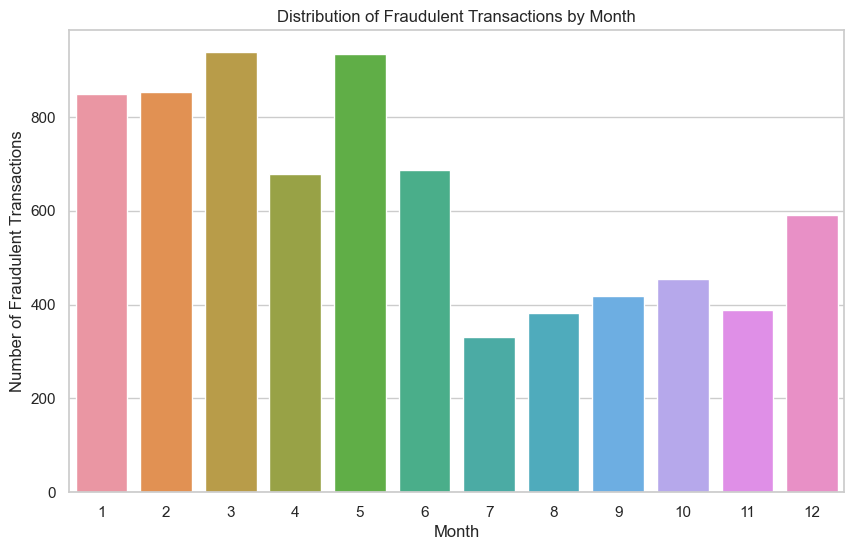

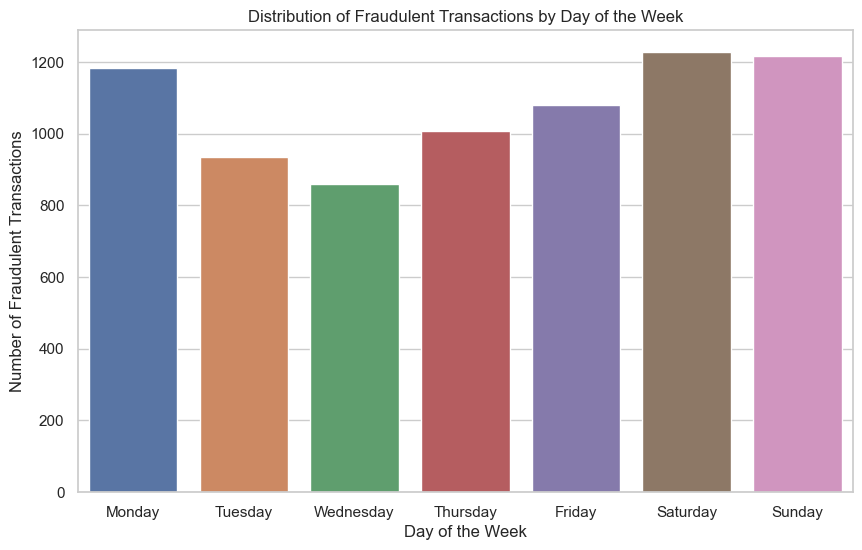

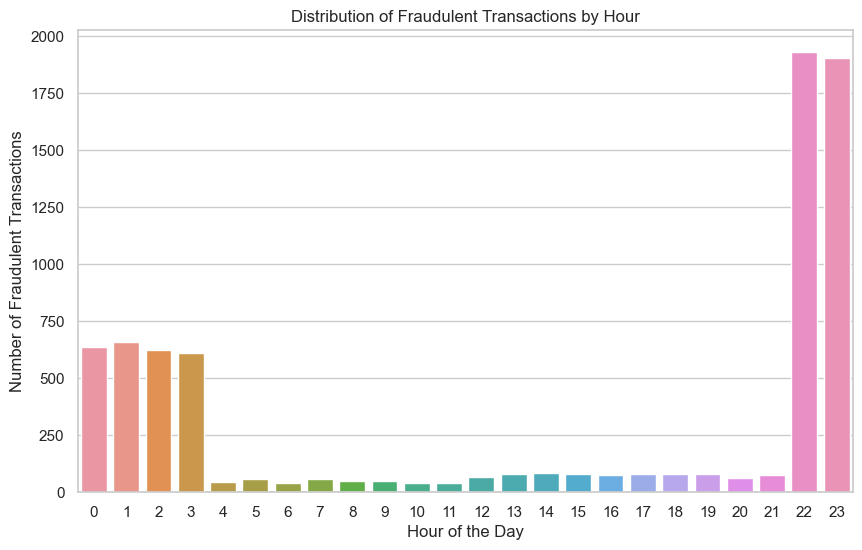

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'trans_date_trans_time' column to datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract date components
df['month'] = df['trans_date_trans_time'].dt.month
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['hour'] = df['trans_date_trans_time'].dt.hour

# Filter fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1]

# Plot the distribution of fraudulent transactions by month
plt.figure(figsize=(10, 6))
sns.countplot(x='month', data=fraudulent_transactions)
plt.title('Distribution of Fraudulent Transactions by Month')
plt.xlabel('Month')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

# Plot the distribution of fraudulent transactions by day of the week
plt.figure(figsize=(10, 6))
sns.countplot(x='day_of_week', data=fraudulent_transactions)
plt.title('Distribution of Fraudulent Transactions by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()

# Plot the distribution of fraudulent transactions by hour
plt.figure(figsize=(10, 6))
sns.countplot(x='hour', data=fraudulent_transactions)
plt.title('Distribution of Fraudulent Transactions by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()


## 6. What are the most common occupations among individuals involved in fraudulent transactions?

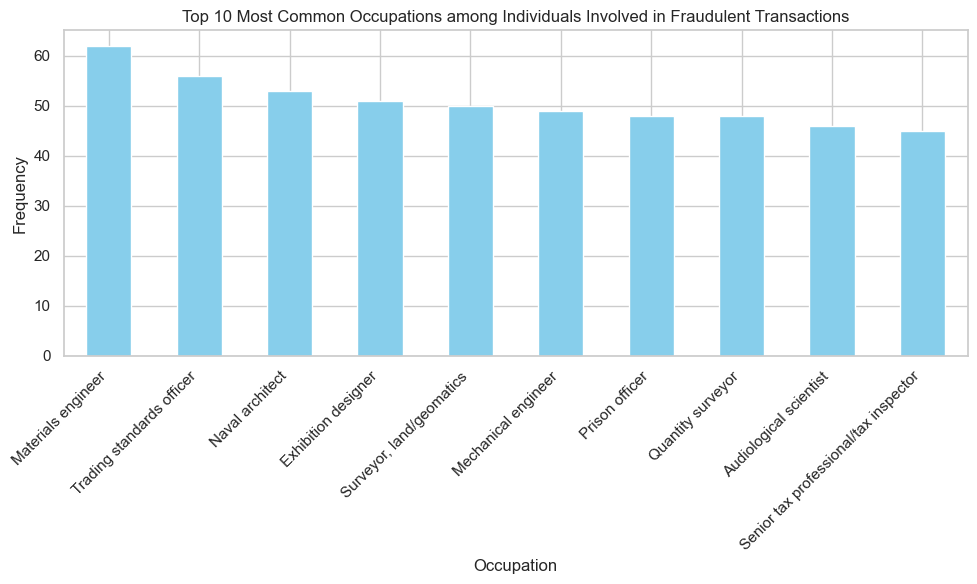

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1]

# Count occurrences of each occupation
occupation_counts = fraudulent_transactions['job'].value_counts()

# Visualize the distribution of occupations
plt.figure(figsize=(10, 6))
occupation_counts.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Common Occupations among Individuals Involved in Fraudulent Transactions')
plt.xlabel('Occupation')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


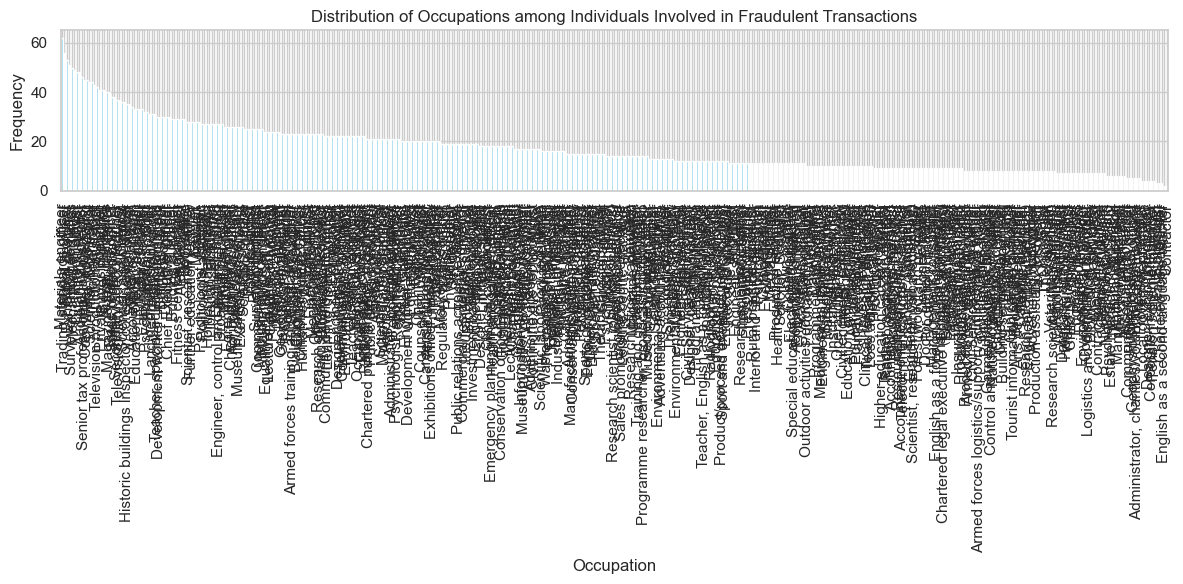

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1]

# Count occurrences of each occupation
occupation_counts = fraudulent_transactions['job'].value_counts()

# Visualize the distribution of occupations
plt.figure(figsize=(12, 6))
occupation_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Occupations among Individuals Involved in Fraudulent Transactions')
plt.xlabel('Occupation')
plt.ylabel('Frequency')
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()


We need to clran this data ex.Mapping to see better result of this distribution

## 7.Are fraudulent transactions more common in certain states or cities?

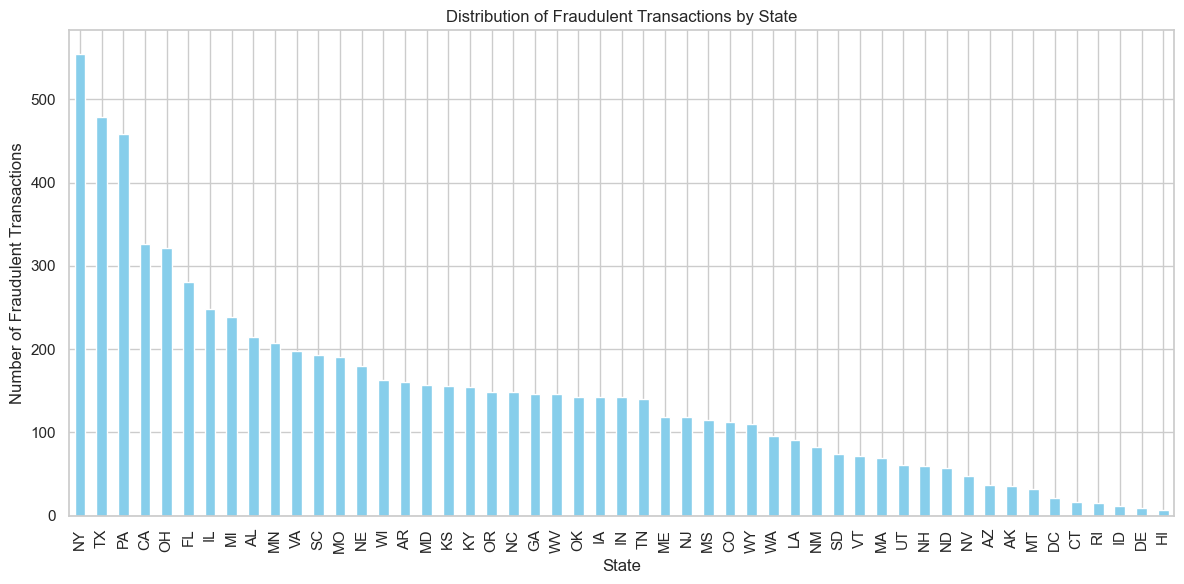

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1]

# Count occurrences of fraudulent transactions by state
state_counts = fraudulent_transactions['state'].value_counts()

# Visualize the distribution of fraudulent transactions by state
plt.figure(figsize=(12, 6))
state_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Fraudulent Transactions by State')
plt.xlabel('State')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

We can do this in TableU for better understanding

AL: Alabama
AK: Alaska
AZ: Arizona
AR: Arkansas
CA: California
CO: Colorado
CT: Connecticut
DE: Delaware
FL: Florida
GA: Georgia
HI: Hawaii
ID: Idaho
IL: Illinois
IN: Indiana
IA: Iowa
KS: Kansas
KY: Kentucky
LA: Louisiana
ME: Maine
MD: Maryland
MA: Massachusetts
MI: Michigan
MN: Minnesota
MS: Mississippi
MO: Missouri
MT: Montana
NE: Nebraska
NV: Nevada
NH: New Hampshire
NJ: New Jersey
NM: New Mexico
NY: New York
NC: North Carolina
ND: North Dakota
OH: Ohio
OK: Oklahoma
OR: Oregon
PA: Pennsylvania
RI: Rhode Island
SC: South Carolina
SD: South Dakota
TN: Tennessee
TX: Texas
UT: Utah
VT: Vermont
VA: Virginia
WA: Washington
WV: West Virginia
WI: Wisconsin
WY: Wyoming

## 8.What is the average population size of cities where fraudulent transactions occur?

In [48]:
# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1]

# Aggregate population size by city
city_population_avg = fraudulent_transactions.groupby('city')['city_pop'].mean()

# Calculate the average population size of cities
average_population_size = city_population_avg.mean()

# Print the average population size
print("Average population size of cities where fraudulent transactions occur:", average_population_size)


Average population size of cities where fraudulent transactions occur: 71525.96156615201


## 9.Do fraudulent transactions tend to occur more frequently during certain times of the day?

C:\Users\Daisy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Daisy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


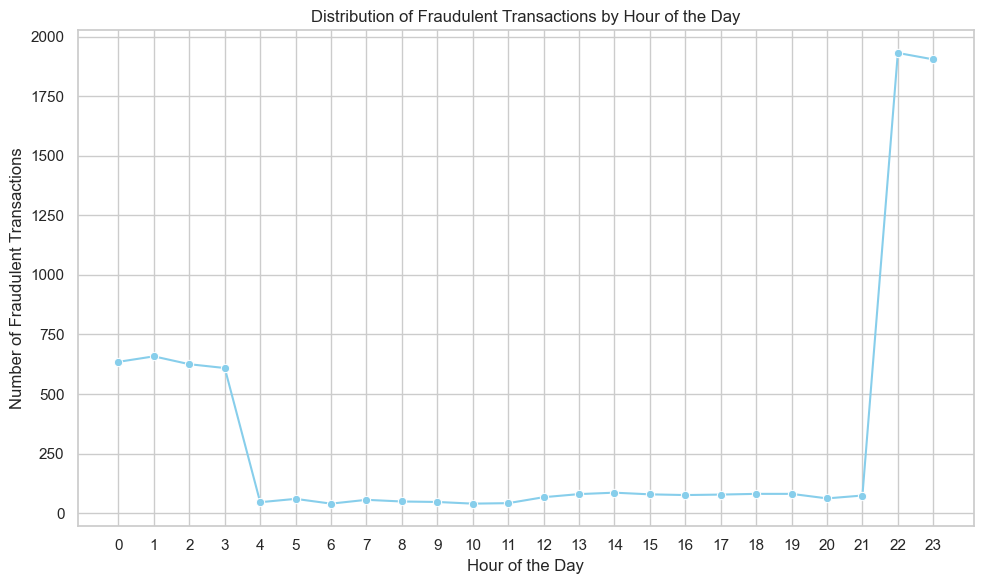

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1].copy()  # Make a copy to avoid modifying the original DataFrame

# Use .loc to set values in the DataFrame explicitly
fraudulent_transactions.loc[:, 'hour'] = fraudulent_transactions['trans_date_trans_time'].dt.hour

# Aggregate transactions by hour of the day
fraudulent_transactions_by_hour = fraudulent_transactions.groupby('hour').size()

# Visualize the distribution of fraudulent transactions by hour
plt.figure(figsize=(10, 6))
sns.lineplot(x=fraudulent_transactions_by_hour.index, y=fraudulent_transactions_by_hour.values, marker='o', color='skyblue')
plt.title('Distribution of Fraudulent Transactions by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Daisy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Daisy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


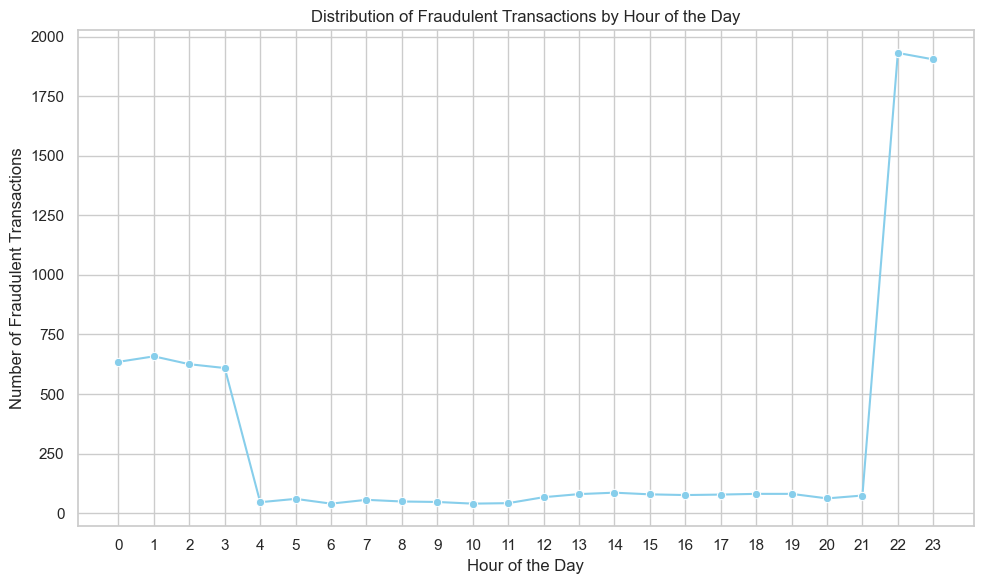

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert 'trans_date_trans_time' column to datetime format if not already done
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Filter the DataFrame for fraudulent transactions
fraudulent_transactions = df[df['is_fraud'] == 1].copy()  # Make a copy to avoid modifying the original DataFrame

# Use .loc to set values in the DataFrame explicitly
fraudulent_transactions.loc[:, 'hour'] = fraudulent_transactions['trans_date_trans_time'].dt.hour

# Aggregate transactions by hour of the day
fraudulent_transactions_by_hour = fraudulent_transactions.groupby('hour').size()

# Visualize the distribution of fraudulent transactions by hour
plt.figure(figsize=(10, 6))
sns.lineplot(x=fraudulent_transactions_by_hour.index, y=fraudulent_transactions_by_hour.values, marker='o', color='skyblue')
plt.title('Distribution of Fraudulent Transactions by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()


Seems like at 10 pm is the most occues fraudulants

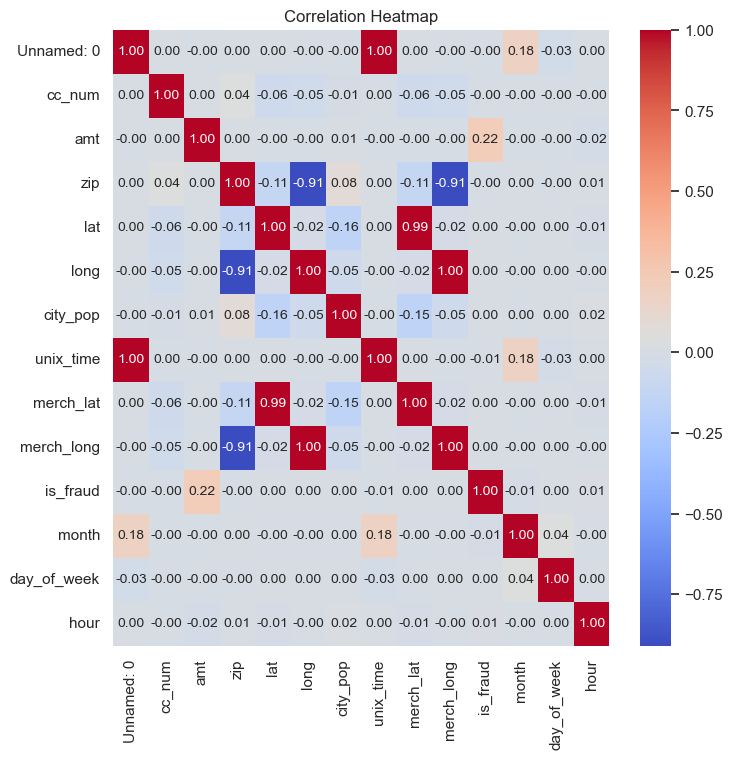

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Correlation Heatmap')
plt.show()


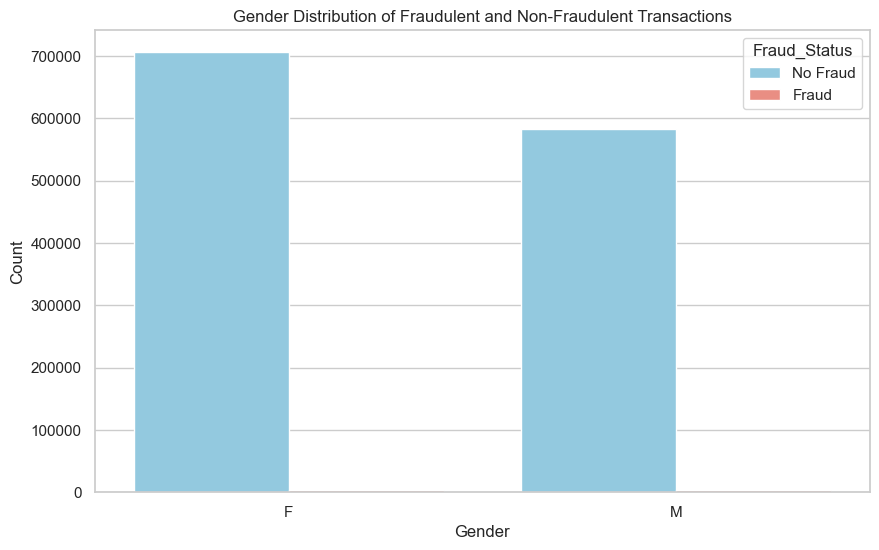

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group the data by gender and is_fraud and get the counts
gender_fraud_counts = df.groupby(['gender', 'is_fraud']).size().reset_index(name='count')

# Create a pivot table for easier plotting
pivot_table = gender_fraud_counts.pivot(index='gender', columns='is_fraud', values='count').reset_index()

# Rename the columns for better understanding
pivot_table.columns = ['gender', 'No Fraud', 'Fraud']

# Fill NaN values with 0
pivot_table = pivot_table.fillna(0)

# Melt the pivot table for Seaborn
melted_table = pivot_table.melt(id_vars='gender', value_vars=['No Fraud', 'Fraud'], var_name='Fraud_Status', value_name='count')

# Plot the grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='gender', y='count', hue='Fraud_Status', data=melted_table, palette=['skyblue', 'salmon'])
plt.title('Gender Distribution of Fraudulent and Non-Fraudulent Transactions')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

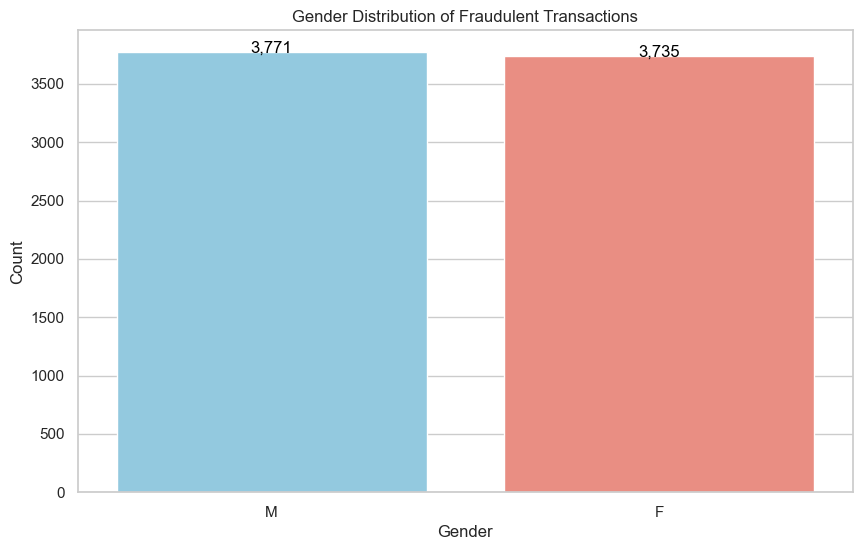

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the data to include only fraudulent transactions
fraud_data = df[df['is_fraud'] == 1]

# Group the data by gender and get the counts
gender_fraud_counts = fraud_data['gender'].value_counts().reset_index()
gender_fraud_counts.columns = ['gender', 'count']

# Plot the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='gender', y='count', data=gender_fraud_counts, palette=['skyblue', 'salmon'])
plt.title('Gender Distribution of Fraudulent Transactions')
plt.xlabel('Gender')
plt.ylabel('Count')

# Annotate the bars with the count values formatted with commas
for index, row in gender_fraud_counts.iterrows():
    plt.text(row.name, row['count'], f'{row["count"]:,}', color='black', ha="center")

plt.show()


Similar porpotion of fraudulant case between 2 genders